[load_yaml] Loaded /Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/models/autoencoder/params.yaml
Using device: mps
Using sample: /Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test/rgb_images/categories_with_handpicked_training_samples/holes/TObject_1721980858444_0.png


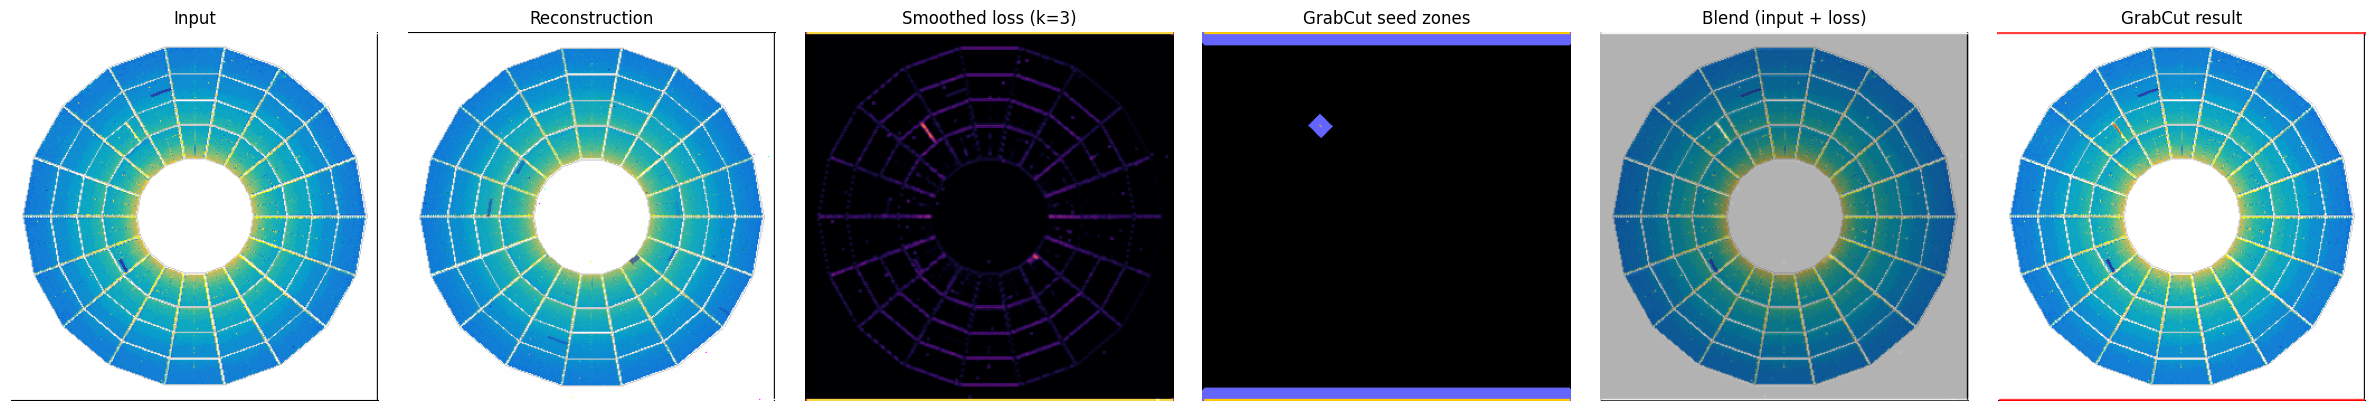

Seed pixels: 1310  |  Final mask pixels: 1325


In [7]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from mlflow.tracking import MlflowClient
from scipy.ndimage import binary_dilation
from torchvision import transforms


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "models/autoencoder/params.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root.")


def overlay_mask_on_image(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    overlay = image.copy()
    overlay[mask.astype(bool), 0] = 1.0
    overlay[mask.astype(bool), 1] *= 0.25
    overlay[mask.astype(bool), 2] *= 0.25
    return np.clip(overlay, 0.0, 1.0)


def main():
    repo_root = find_repo_root(Path.cwd())
    ae_dir = repo_root / "models" / "autoencoder"
    sys.path.insert(0, str(ae_dir))

    from utils import load_yaml
    cfg = load_yaml(ae_dir / "params.yaml")

    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    mlflow.set_tracking_uri(cfg["mlflow"]["tracking"]["server_uri"])
    client = MlflowClient()
    model_name = cfg["inference"].get("model_name", cfg["testing"]["model_name"])
    versions = list(client.search_model_versions(f"name='{model_name}'"))
    latest = max(versions, key=lambda mv: int(mv.version))
    model = mlflow.pytorch.load_model(latest.source).to(device).eval()

    sample_path = sorted((repo_root / "data/tpc/test/rgb_images/categories_with_handpicked_training_samples/holes").rglob("*.png"))[9]
    print(f"Using sample: {sample_path}")
    
    VFLIP               = True  
    x = transforms.ToTensor()(Image.open(sample_path).convert("RGB")).unsqueeze(0).to(device)
    if VFLIP:
        x = torch.flip(x, dims=[-2]).contiguous()
    with torch.no_grad():
        recon = model(x)

    # Parameters
    smoothing_kernel    = 3
    threshold_ratio     = 0.7
    buffer_dilation     = 10    # px around seed = probable background zone
    grabcut_iters       = 3
    loss_blend_weight   = 0.3   # 0=pure input image, 1=pure loss map

    # Loss map -> blur -> threshold (seed)
    loss_map = ((x - recon) ** 2).mean(dim=1, keepdim=True)
    smoothed  = F.avg_pool2d(loss_map, kernel_size=smoothing_kernel, stride=1, padding=smoothing_kernel // 2)

    threshold = threshold_ratio * float(smoothed.max())
    seed_mask = (smoothed > threshold).squeeze().cpu().numpy().astype(np.uint8)

    # Blend input + loss map for GrabCut
    img_np   = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    loss_np  = smoothed.squeeze().cpu().numpy()

    loss_uint8 = (loss_np / loss_np.max() * 255).astype(np.uint8)
    loss_rgb   = np.stack([loss_uint8] * 3, axis=-1)
    blend      = ((1 - loss_blend_weight) * (img_np * 255) + loss_blend_weight * loss_rgb).astype(np.uint8)
    blend_bgr  = cv2.cvtColor(blend, cv2.COLOR_RGB2BGR)

    # GrabCut mask with explicit background zones
    near_seed = binary_dilation(seed_mask.astype(bool), iterations=buffer_dilation)

    grabcut_mask = np.full_like(seed_mask, cv2.GC_BGD)           # far from seed: sure background
    grabcut_mask[near_seed] = cv2.GC_PR_BGD                      # buffer zone: probable background
    grabcut_mask[seed_mask.astype(bool)] = cv2.GC_PR_FGD         # seed: probable foreground

    bgd_model, fgd_model = np.zeros((1, 65), np.float64), np.zeros((1, 65), np.float64)
    cv2.grabCut(blend_bgr, grabcut_mask, None, bgd_model, fgd_model, grabcut_iters, cv2.GC_INIT_WITH_MASK)
    final_mask = np.where((grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

    recon_np    = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()
    smoothed_np = loss_np

    # Visualize the 3-zone GrabCut seed
    seed_viz = np.zeros((*seed_mask.shape, 3), dtype=np.uint8)
    seed_viz[near_seed] = [100, 100, 255]                        # blue = probable background
    seed_viz[seed_mask.astype(bool)] = [255, 200, 0]             # yellow = probable foreground

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    axes[0].imshow(img_np);                                      axes[0].set_title("Input")
    axes[1].imshow(recon_np);                                    axes[1].set_title("Reconstruction")
    axes[2].imshow(smoothed_np, cmap="inferno");                 axes[2].set_title(f"Smoothed loss (k={smoothing_kernel})")
    axes[3].imshow(seed_viz);                                    axes[3].set_title("GrabCut seed zones")
    axes[4].imshow(cv2.cvtColor(blend_bgr, cv2.COLOR_BGR2RGB));  axes[4].set_title("Blend (input + loss)")
    axes[5].imshow(overlay_mask_on_image(img_np, final_mask));   axes[5].set_title("GrabCut result")

    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Seed pixels: {seed_mask.sum()}  |  Final mask pixels: {final_mask.sum()}")


if __name__ == "__main__":
    main()